# 07-3. 검증과 재검색 루프가 있는 Tavily 뉴스 에이전트

이 실습은 2단계 검색 리포트 그래프에 검증 노드와 재검색 루프를 추가하는 예제이다.

## 학습 목표

1. 검색 결과가 충분한지 검증하는 노드를 만든다.
2. 조건부 Edge로 `리포트작성` 또는 `검색어재작성`으로 분기한다.
3. 검색 결과가 부족하면 검색어를 바꾸어 다시 검색한다.
4. 무한 루프를 막기 위해 최대 검색 횟수를 제한한다.

## 전체 흐름

```text
START
  ↓
검색
  ↓
검증
  ├─ 충분함 → 리포트작성 → END
  └─ 부족함 → 검색어재작성 → 검색
```

이 단계는 앞선 두 실습을 모두 이해한 뒤 진행하는 확장 실습이다.


## 0. 설치 패키지

이 실습은 LangGraph, OpenAI 모델, Tavily 검색 도구를 사용한다.  
처음 실행하는 환경에서는 아래 명령으로 필요한 패키지를 설치한다.

```bash
uv add langgraph langchain-openai langchain-tavily langchain-core python-dotenv grandalf
```

`.env` 파일에는 다음 값을 설정한다.

```text
OPENAI_API_KEY=발급받은_OpenAI_API_Key
TAVILY_API_KEY=발급받은_Tavily_API_Key
```


In [1]:
# 공통 환경 설정
# - .env 파일에서 API Key를 읽는다.
# - API Key가 없으면 실습 초반에 명확한 오류를 발생시킨다.
import os
from dotenv import load_dotenv

load_dotenv(override=True, dotenv_path="../.env")

OPENAI_API_KEY = os.getenv("OPENAI_API_KEY")
TAVILY_API_KEY = os.getenv("TAVILY_API_KEY")

if not OPENAI_API_KEY:
    raise ValueError("OPENAI_API_KEY가 설정되어 있지 않다. ../.env 파일을 확인한다.")

if not TAVILY_API_KEY:
    raise ValueError("TAVILY_API_KEY가 설정되어 있지 않다. ../.env 파일을 확인한다.")

print("환경 변수 로드 완료")


환경 변수 로드 완료


In [2]:
# LangGraph, LLM, Tavily 검색 도구를 불러온다.
from typing_extensions import TypedDict
from langgraph.graph import StateGraph, START, END
from langchain_tavily import TavilySearch
from langchain_openai import ChatOpenAI
from langchain_core.prompts import ChatPromptTemplate
from langchain_core.output_parsers import StrOutputParser
from IPython.display import Image, display

# LLM은 검색 결과를 자연어 리포트로 정리할 때 사용한다.
llm = ChatOpenAI(model="gpt-4o-mini", temperature=0.2)

# TavilySearch는 외부 웹 검색을 수행하는 도구이다.
tavily_tool = TavilySearch(max_results=5)


In [3]:
def normalize_tavily_results(raw_result) -> list[dict]:
    """Tavily 검색 결과를 list[dict] 형태로 정리한다.

    TavilySearch의 반환값은 보통 {"results": [...]} 형태이다.
    실습에서는 이후 노드가 사용하기 쉽도록 검색 결과 리스트만 추출한다.
    """
    if isinstance(raw_result, dict):
        return raw_result.get("results", [])

    if isinstance(raw_result, list):
        return raw_result

    return []


def format_search_results(results: list[dict]) -> str:
    """검색 결과를 LLM 프롬프트에 넣기 쉬운 문자열로 변환한다."""
    if not results:
        return "검색 결과가 없다."

    lines = []
    for idx, item in enumerate(results, start=1):
        title = item.get("title", "제목 없음")
        url = item.get("url", "URL 없음")
        content = item.get("content", "내용 없음")

        lines.append(
            f"[{idx}] {title}\n"
            f"URL: {url}\n"
            f"내용: {content}"
        )

    return "\n\n".join(lines)


def show_graph(app):
    """그래프 구조를 시각화한다.

    Mermaid 이미지 생성이 실패하면 ASCII 그래프로 대체한다.
    """
    try:
        display(Image(app.get_graph().draw_mermaid_png()))
    except Exception as e:
        print(f"Mermaid 이미지 생성 실패: {e}")
        print(app.get_graph().draw_ascii())


## 1. State 정의

3단계에서는 조건부 분기와 재검색을 위해 State 필드가 늘어난다.

| 필드 | 의미 |
|---|---|
| `topic` | 사용자가 입력한 원래 주제 |
| `search_query` | 현재 검색어 |
| `search_results` | 현재 검색 결과 |
| `is_sufficient` | 검색 결과가 충분한지 여부 |
| `feedback` | 검증 결과 또는 재검색 이유 |
| `search_count` | 검색을 실행한 횟수 |
| `report` | 최종 리포트 |


In [4]:
class AdvancedNewsState(TypedDict):
    # 사용자가 입력한 원래 주제이다.
    topic: str

    # 현재 Tavily 검색에 사용할 검색어이다.
    search_query: str

    # 현재 검색 결과 목록이다.
    search_results: list[dict]

    # 검색 결과가 리포트 작성에 충분한지 표시한다.
    is_sufficient: bool

    # 검증 결과나 재검색 이유를 저장한다.
    feedback: str

    # 검색이 몇 번 실행되었는지 저장한다.
    search_count: int

    # 최종 리포트이다.
    report: str


## 2. 검색 노드 정의

검색 노드는 현재 `search_query`를 사용한다.  
단, 처음 실행할 때 `search_query`가 비어 있으면 `topic`을 검색어로 사용한다.

재검색 루프가 발생하면 `검색어재작성` 노드가 만든 새 검색어를 사용한다.


In [5]:
def search_node(state: AdvancedNewsState) -> dict:
    """현재 검색어로 Tavily 검색을 수행하는 노드이다."""

    # search_query가 비어 있으면 topic을 검색어로 사용한다.
    query = state.get("search_query") or state["topic"]

    # 검색 횟수를 1 증가시킨다.
    search_count = state.get("search_count", 0) + 1

    print(f"[{search_count}회차 검색] {query}")

    raw_result = tavily_tool.invoke({"query": query})
    results = normalize_tavily_results(raw_result)

    print(f"검색 결과 수: {len(results)}")

    return {
        "search_query": query,
        "search_results": results,
        "search_count": search_count,
    }


## 3. 검증 노드 정의

검증 노드는 검색 결과가 충분한지 판단한다.

초보자 실습에서는 기준을 단순하게 둔다.

- 검색 결과가 3개 이상이면 충분하다고 본다.
- 최대 검색 횟수에 도달하면 더 이상 재검색하지 않는다.

실무에서는 URL 신뢰도, 날짜, 중복 여부, 원문 길이 등을 추가로 검증할 수 있다.


In [6]:
MAX_SEARCH_COUNT = 2


def validate_node(state: AdvancedNewsState) -> dict:
    """검색 결과가 충분한지 판단하는 노드이다."""

    results = state["search_results"]
    search_count = state["search_count"]

    # 초보자 실습에서는 검색 결과 개수만으로 충분성을 판단한다.
    has_enough_results = len(results) >= 3

    # 무한 재검색을 막기 위해 최대 검색 횟수를 제한한다.
    reached_limit = search_count >= MAX_SEARCH_COUNT

    if has_enough_results:
        return {
            "is_sufficient": True,
            "feedback": "검색 결과가 충분하다.",
        }

    if reached_limit:
        return {
            "is_sufficient": True,
            "feedback": "검색 결과가 충분하지 않지만 최대 검색 횟수에 도달해 리포트를 작성한다.",
        }

    return {
        "is_sufficient": False,
        "feedback": "검색 결과가 부족하다. 더 구체적인 검색어가 필요하다.",
    }


## 4. 검색어 재작성 노드 정의

검색 결과가 부족하면 LLM을 사용해 검색어를 다시 작성한다.

이 노드는 `search_query`만 변경한다.  
다음 검색 노드는 변경된 검색어를 사용한다.


In [7]:
rewrite_prompt = ChatPromptTemplate.from_messages([
    (
        "system",
        """
너는 웹 검색어를 개선하는 AI이다.
사용자의 주제와 피드백을 바탕으로 더 구체적인 한국어 검색어 하나만 작성한다.
설명 없이 검색어만 출력한다.
""".strip(),
    ),
    (
        "human",
        """
원래 주제: {topic}
현재 검색어: {search_query}
피드백: {feedback}

개선된 검색어:
""".strip(),
    ),
])

rewrite_chain = rewrite_prompt | llm | StrOutputParser()


def rewrite_query_node(state: AdvancedNewsState) -> dict:
    """검색 결과가 부족할 때 검색어를 다시 작성하는 노드이다."""

    new_query = rewrite_chain.invoke({
        "topic": state["topic"],
        "search_query": state["search_query"],
        "feedback": state["feedback"],
    }).strip()

    print(f"재작성된 검색어: {new_query}")

    return {"search_query": new_query}


## 5. 리포트 작성 노드 정의

리포트 작성 노드는 현재 검색 결과와 검증 피드백을 함께 사용한다.  
검색 결과가 부족한 상태로 최대 검색 횟수에 도달했을 수도 있으므로, 한계도 리포트에 반영한다.


In [8]:
report_prompt = ChatPromptTemplate.from_messages([
    (
        "system",
        """
너는 검색 결과를 바탕으로 짧은 뉴스 브리핑을 작성하는 AI이다.

작성 규칙:
1. 검색 결과에 있는 내용만 사용한다.
2. 날짜, 수치, 기관명은 원문에 있을 때만 사용한다.
3. 제공되지 않은 정보는 추정하지 않는다.
4. 검색 결과가 부족하면 한계를 명시한다.
5. 한국어로 작성한다.
""".strip(),
    ),
    (
        "human",
        """
주제: {topic}
검색어: {search_query}
검증 피드백: {feedback}

검색 결과:
{search_results}

위 내용을 바탕으로 뉴스 리포트를 작성하라.
""".strip(),
    ),
])

report_chain = report_prompt | llm | StrOutputParser()


def report_node(state: AdvancedNewsState) -> dict:
    """검색 결과를 바탕으로 최종 리포트를 작성하는 노드이다."""

    search_text = format_search_results(state["search_results"])

    report = report_chain.invoke({
        "topic": state["topic"],
        "search_query": state["search_query"],
        "feedback": state["feedback"],
        "search_results": search_text,
    })

    return {"report": report}


## 6. 라우팅 함수 정의

조건부 Edge는 라우팅 함수의 반환값에 따라 다음 노드를 선택한다.

- `is_sufficient=True`이면 `리포트작성`으로 이동한다.
- `is_sufficient=False`이면 `검색어재작성`으로 이동한다.


In [9]:
def route_after_validation(state: AdvancedNewsState) -> str:
    """검증 결과에 따라 다음 노드를 선택한다."""

    if state["is_sufficient"]:
        return "리포트작성"

    return "검색어재작성"


## 7. 그래프 구성

조건부 Edge와 루프를 포함한 그래프를 구성한다.

`path_map`을 명시하면 라우팅 함수의 반환값과 실제 이동할 노드의 관계가 분명해진다.  
그래프 시각화도 더 정확하게 표시된다.


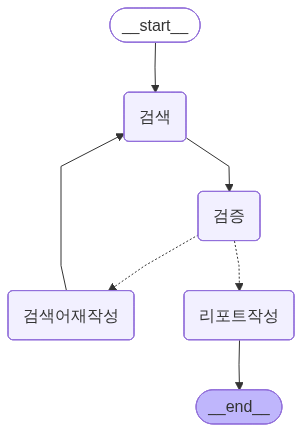

In [10]:
builder = StateGraph(AdvancedNewsState)

builder.add_node("검색", search_node)
builder.add_node("검증", validate_node)
builder.add_node("검색어재작성", rewrite_query_node)
builder.add_node("리포트작성", report_node)

builder.add_edge(START, "검색")
builder.add_edge("검색", "검증")

# 검증 결과에 따라 리포트 작성 또는 검색어 재작성으로 분기한다.
builder.add_conditional_edges(
    "검증",
    route_after_validation,
    {
        "리포트작성": "리포트작성",
        "검색어재작성": "검색어재작성",
    },
)

# 검색어를 다시 작성하면 검색 노드로 돌아간다.
builder.add_edge("검색어재작성", "검색")

builder.add_edge("리포트작성", END)

app = builder.compile()

show_graph(app)


## 8. 그래프 실행

검색 결과가 충분하면 한 번만 검색하고 리포트를 작성한다.  
검색 결과가 부족하면 검색어를 다시 작성하고 한 번 더 검색한다.


In [11]:
initial_state = {
    "topic": "인공지능 최신 동향",
    "search_query": "",
    "search_results": [],
    "is_sufficient": False,
    "feedback": "",
    "search_count": 0,
    "report": "",
}

result = app.invoke(initial_state)

print("최종 검색어:", result["search_query"])
print("검색 횟수:", result["search_count"])
print("검증 피드백:", result["feedback"])
print("\n[최종 리포트]")
print(result["report"])


[1회차 검색] 인공지능 최신 동향
검색 결과 수: 5
최종 검색어: 인공지능 최신 동향
검색 횟수: 1
검증 피드백: 검색 결과가 충분하다.

[최종 리포트]
최근 인공지능(AI) 분야에서의 기술 동향이 주목받고 있습니다. AI 산업은 생성적 AI의 출현 이후 급속히 성장하고 있으며, 주요 기업들이 막대한 자본과 컴퓨팅 파워를 바탕으로 혁신적인 AI 모델 개발에 박차를 가하고 있습니다. 특히, 다중 모달 모델의 등장, AI의 현실 이해 능력 강화, 저전력 및 경량 모델 개발, 인공지능 일반 지능 및 대체 아키텍처 개발 등이 주요 기술 발전 방향으로 부각되고 있습니다.

또한, AI 기술의 발전 속도가 가속화됨에 따라 신뢰할 수 있는 정보원의 필요성이 커지고 있습니다. 국내외 주요 AI 정보 허브들이 최신 연구 동향과 기업 혁신 사례를 심층적으로 분석하여 AI 생태계의 현주소를 파악하는 데 기여하고 있습니다.

글로벌 IT 기업들은 AI 기술 개발과 투자를 지속적으로 확대하고 있으며, 특히 음성 인식 및 사물인터넷(IoT)과 자율주행 자동차 분야에서의 활용이 두드러지고 있습니다. 그러나 국내 AI 관련 투자와 기술 수준은 여전히 미미한 상황입니다.

이와 같은 동향은 AI 기술이 우리 생활에 점점 더 깊숙이 자리 잡고 있음을 보여주며, 앞으로의 발전이 기대됩니다.


## 9. stream으로 실행 흐름 확인

`stream_mode="updates"`를 사용하면 각 노드가 어떤 값을 반환했는지 단계별로 확인할 수 있다.


In [12]:
for event in app.stream(initial_state, stream_mode="updates"):
    print(event.keys())
    print(event)
    print("-" * 80)


[1회차 검색] 인공지능 최신 동향
검색 결과 수: 5
dict_keys(['검색'])
{'검색': {'search_query': '인공지능 최신 동향', 'search_results': [{'url': 'https://tobetong.com/ai-part-2-ai%EC%9D%98-%ED%98%84%EC%9E%AC%EC%99%80-%EB%82%98%EC%95%84%EA%B0%88-%EA%B8%B8_ai%EC%9D%98-%EC%B5%9C%EC%8B%A0-%EA%B8%B0%EC%88%A0-%EB%8F%99%ED%96%A5-%EC%B4%9D%EC%A0%95%EB%A6%AC', 'title': '[AI Part.2] AI의 현재와 나아갈 길_AI의 최신 기술 동향 총정리 - 투비통', 'content': 'AI의 최신 기술 동향을 다루며, 데이터 마이닝, 영상 처리, 자연어 처리, GPT-4o 등 다양한 분야의 최신 기술들을 소개하겠습니다.', 'score': 0.9995234, 'raw_content': None}, {'url': 'https://ettrends.etri.re.kr/ettrends/212/0905212008/0905212008.html', 'title': '인공지능 분야 산업·기술 동향 및 이슈', 'content': '# 인공지능 분야 산업·기술 동향 및 이슈. Key Trends and Issues in Artificial Intelligence. The artificial intelligence (AI) industry has grown rapidly since the advent of generative AI, and AI services have recently been applied in real life and are expanding in scope. Major companies in the AI field, including big tech companies, are leading the research and development 

In [13]:
for event in app.stream(
    {
        "topic": "생성형 AI 교육 트렌드, url 오픈 가능한 자료만 추출하기",
        "search_query": "",
        "search_results": [],
        "report": "",
    },
    stream_mode="updates",
):    
    
    for update_data in event.values():
        if "search_results" in update_data:
            for i, item in enumerate(update_data["search_results"], start=1):
                print(f"\n[{i}] {item.get('title')}")
                print(item.get("url"))
                print(item.get("content"))

[1회차 검색] 생성형 AI 교육 트렌드, url 오픈 가능한 자료만 추출하기
검색 결과 수: 5

[1] 슬래시 명령어 2개로 AI 트렌드 리서치 자동화하기 - 지피터스
https://www.gpters.org/nocode/post/automate-ai-trend-research-RQvsDXxztDI1htZ
목표. "URL만 주면 자동으로 내용 추출하고 마크다운으로 저장". 더 나아가서, 검색 키워드만 입력하면 관련 URL까지 찾아주면 좋겠다고 생각했어요.

[2] [PDF] 4차산업시대의생성형AI활용가이드.pdf
https://ecampus.pro.ac.kr/pluginfile.php/39/mod_ubboard/attachment/59496/4%EC%B0%A8%EC%82%B0%EC%97%85%EC%8B%9C%EB%8C%80%EC%9D%98%EC%83%9D%EC%84%B1%ED%98%95AI%ED%99%9C%EC%9A%A9%EA%B0%80%EC%9D%B4%EB%93%9C.pdf?forcedownload=1
Open AI 사이트 접속 및 Sign up 선택하기. 1. 이메일 주소(계정)생성 및 비밀번호 입력하기 ... 학습자료와 오픈소스 문제. 생성물의 저작물성25). - 오픈 소스 라이선스에

[3] May 13, 2026 [Searching for Academic Resources with AI ... - YouTube
https://www.youtube.com/watch?v=BghfRpw0tMw
2026년 5월 13일 [초심자를 위한 AI로 학술자료 검색하기] |  AI검색, 결과수집, 요약, 글쓰기, 탐지, 출판윤리
가톨릭대학교 성의교정도서관 아카이브
504 subscribers
3 likes
35 views
14 May 2026
안녕하세요! 리서치와 논문 작성이 막막한 초심자분들을 위해 준비했습니다.
가톨릭대학교 성의교정 도서관에서 진행된 교육 자료를 바탕으로, AI를 활용해 더 스마트하고 빠르게 학술 자료를 검색하고 관리하는 방법을 핵심만 쏙쏙 뽑아

## 정리

이 단계에서 확인한 내용은 다음과 같다.

1. 조건부 Edge는 State 값에 따라 다음 노드를 다르게 선택한다.
2. 검색 결과가 부족하면 검색어를 다시 작성하고 검색 노드로 돌아갈 수 있다.
3. 루프를 사용할 때는 최대 반복 횟수 같은 안전장치가 필요하다.
4. 이 구조는 검색 기반 리포트 생성, 상품 추천, 문서 검토, RAG 품질 개선 등에 응용할 수 있다.


---

## 핵심 정리

```python
# 1. Tavily Search 도구 초기화
from langchain_tavily import TavilySearch

tavily_tool = TavilySearch(max_results=5)

raw_result = tavily_tool.invoke({"query": "검색어"})
results = raw_result["results"]


# 2. State 정의
from typing_extensions import TypedDict

class AdvancedNewsState(TypedDict):
    topic: str
    search_query: str
    search_results: list[dict]
    is_sufficient: bool
    feedback: str
    search_count: int
    report: str


# 3. 검색 노드
def search_node(state: AdvancedNewsState) -> dict:
    query = state.get("search_query") or state["topic"]
    search_count = state.get("search_count", 0) + 1

    raw_result = tavily_tool.invoke({"query": query})
    results = normalize_tavily_results(raw_result)

    return {
        "search_query": query,
        "search_results": results,
        "search_count": search_count,
    }


# 4. 검증 노드
MAX_SEARCH_COUNT = 2

def validate_node(state: AdvancedNewsState) -> dict:
    results = state["search_results"]
    search_count = state["search_count"]

    has_enough_results = len(results) >= 3
    reached_limit = search_count >= MAX_SEARCH_COUNT

    if has_enough_results:
        return {
            "is_sufficient": True,
            "feedback": "검색 결과가 충분하다.",
        }

    if reached_limit:
        return {
            "is_sufficient": True,
            "feedback": "검색 결과가 충분하지 않지만 최대 검색 횟수에 도달해 리포트를 작성한다.",
        }

    return {
        "is_sufficient": False,
        "feedback": "검색 결과가 부족하다. 더 구체적인 검색어가 필요하다.",
    }


# 5. 조건부 Edge로 검증 후 분기
def route_after_validation(state: AdvancedNewsState) -> str:
    if state["is_sufficient"]:
        return "리포트작성"

    return "검색어재작성"


builder.add_conditional_edges(
    "검증",
    route_after_validation,
    {
        "리포트작성": "리포트작성",
        "검색어재작성": "검색어재작성",
    },
)


# 6. 재검색 루프
builder.add_edge("검색어재작성", "검색")
```
- 노드 설명
  
| 노드 | 역할 |
|---|---|
| 검색 | 현재 검색어로 Tavily Search API를 호출해 웹 검색을 수행한다. |
| 검증 | 검색 결과 개수와 최대 검색 횟수를 기준으로 결과가 충분한지 판단한다. |
| 검색어재작성 | 검색 결과가 부족할 때 LLM으로 더 구체적인 검색어를 생성한다. |
| 리포트작성 | 최종 검색 결과와 검증 피드백을 바탕으로 뉴스 리포트를 작성한다. |

- State 필드 설명

| State 필드 | 의미 |
|---|---|
| `topic` | 사용자가 입력한 원래 주제이다. |
| `search_query` | 현재 Tavily 검색에 사용하는 검색어이다. |
| `search_results` | Tavily에서 반환한 현재 검색 결과 목록이다. |
| `is_sufficient` | 검색 결과가 리포트 작성에 충분한지 나타내는 값이다. |
| `feedback` | 검증 결과 또는 재검색이 필요한 이유이다. |
| `search_count` | 검색 노드가 실행된 횟수이다. |
| `report` | LLM이 작성한 최종 뉴스 리포트이다. |

이 실습은 LangGraph에서 **외부 API 호출, 조건부 분기, 재검색 루프, LLM 기반 검색어 재작성, LLM 리포트 작성**을 하나의 그래프로 구성하는 예제이다.

핵심 흐름은 다음과 같다.

```text
START
  ↓
검색
  ↓
검증
  ├─ 충분함 → 리포트작성 → END
  └─ 부족함 → 검색어재작성 → 검색
```

07-2 실습이 `검색 → 리포트작성`의 단순 파이프라인이었다면, 07-3 실습은 여기에 **검증 노드와 재검색 루프**를 추가한 구조이다.

이 구조에서 가장 중요한 부분은 다음 두 가지이다.

1. `검증` 노드는 State의 `is_sufficient` 값을 결정한다.
2. 조건부 Edge는 `is_sufficient` 값에 따라 `리포트작성`으로 갈지, `검색어재작성`으로 갈지 결정한다.

따라서 07-3 실습의 핵심은 단순히 검색 결과를 리포트로 만드는 것이 아니라, **검색 결과의 품질을 확인하고 부족하면 다시 검색하는 Agentic Workflow**를 구성하는 데 있다.